In [1]:
from pathlib import Path
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from pillow_heif import register_heif_opener

import tensorflow as tf
from ultralytics import YOLO

from sklearn.metrics import confusion_matrix, classification_report


In [2]:
# Пути
DATASET_ROOT = Path(r"D:/my_dataset")
TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

# Параметры
SPLIT_RATIO = 0.8
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 17
YOLO_MODEL_NAME = "yolo11n-cls.pt"

SUPPORTED_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}
HEIC_EXTS = {".heic", ".heif"}

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

register_heif_opener()

print("TensorFlow:", tf.__version__)
print("Dataset root:", DATASET_ROOT)

TensorFlow: 2.21.0
Dataset root: D:\my_dataset


In [3]:
# функции подготовки датасета
def convert_heic_to_jpg(root: Path, delete_original: bool = False):
    print("=== Конвертация HEIC/HEIF в JPG ===")
    converted_count = 0

    for file_path in root.rglob("*"):
        if not file_path.is_file():
            continue

        if file_path.suffix.lower() in HEIC_EXTS:
            jpg_path = file_path.with_suffix(".jpg")
            if jpg_path.exists():
                continue

            try:
                with Image.open(file_path) as img:
                    img = img.convert("RGB")
                    img.save(jpg_path, format="JPEG", quality=95)
                converted_count += 1
                if delete_original:
                    file_path.unlink()
            except Exception as e:
                print(f"Ошибка конвертации {file_path}: {e}")

    print(f"Создано JPG: {converted_count}\n")


def split_train_to_val(train_dir: Path, val_dir: Path, split_ratio: float = 0.8, seed: int = 42):
    print("=== Разбиение train -> train + val ===")
    random.seed(seed)

    if val_dir.exists():
        print(f"Папка {val_dir} уже существует. Разбиение пропущено.\n")
        return

    class_dirs = [d for d in train_dir.iterdir() if d.is_dir()]
    if not class_dirs:
        raise ValueError(f"В папке {train_dir} нет подпапок классов.")

    for class_dir in class_dirs:
        (val_dir / class_dir.name).mkdir(parents=True, exist_ok=True)

    for class_dir in class_dirs:
        images = [
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS
        ]
        random.shuffle(images)
        split_index = int(len(images) * split_ratio)
        val_images = images[split_index:]

        print(
            f"{class_dir.name}: всего={len(images)}, "
            f"train={split_index}, val={len(val_images)}"
        )

        for img_path in val_images:
            target_path = val_dir / class_dir.name / img_path.name
            if target_path.exists():
                target_path = val_dir / class_dir.name / f"{img_path.stem}_val{img_path.suffix}"
            shutil.move(str(img_path), str(target_path))

    print("Разбиение завершено.\n")


def print_dataset_stats(root: Path):
    print("=== Статистика датасета ===")
    for split_name in ["train", "val", "test"]:
        split_path = root / split_name
        if not split_path.exists():
            print(f"{split_name}: Папка отсутствует")
            continue

        print(f"\n{split_name.upper()}:")
        total = 0
        for class_dir in sorted([d for d in split_path.iterdir() if d.is_dir()]):
            cnt = len([
                p for p in class_dir.iterdir()
                if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS
            ])
            total += cnt
            print(f"  {class_dir.name}: {cnt}")
        print(f"  Всего: {total}")
    print()


print("=== Проверка структуры датасета ===")
if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"Не найдена папка: {TRAIN_DIR}")
if not TEST_DIR.exists():
    raise FileNotFoundError(f"Не найдена папка: {TEST_DIR}")

convert_heic_to_jpg(DATASET_ROOT, delete_original=False)
split_train_to_val(TRAIN_DIR, VAL_DIR, split_ratio=SPLIT_RATIO, seed=SEED)
print_dataset_stats(DATASET_ROOT)

=== Проверка структуры датасета ===
=== Конвертация HEIC/HEIF в JPG ===
Создано JPG: 0

=== Разбиение train -> train + val ===
Папка D:\my_dataset\val уже существует. Разбиение пропущено.

=== Статистика датасета ===

TRAIN:
  cat: 593
  dog: 490
  Всего: 1083

VAL:
  cat: 149
  dog: 121
  Всего: 270

TEST:
  cat: 793
  dog: 841
  Всего: 1634



=== Загрузка через TensorFlow/Keras ===
Found 1083 files belonging to 2 classes.
Found 270 files belonging to 2 classes.
Found 1634 files belonging to 2 classes.
Классы: ['cat', 'dog']


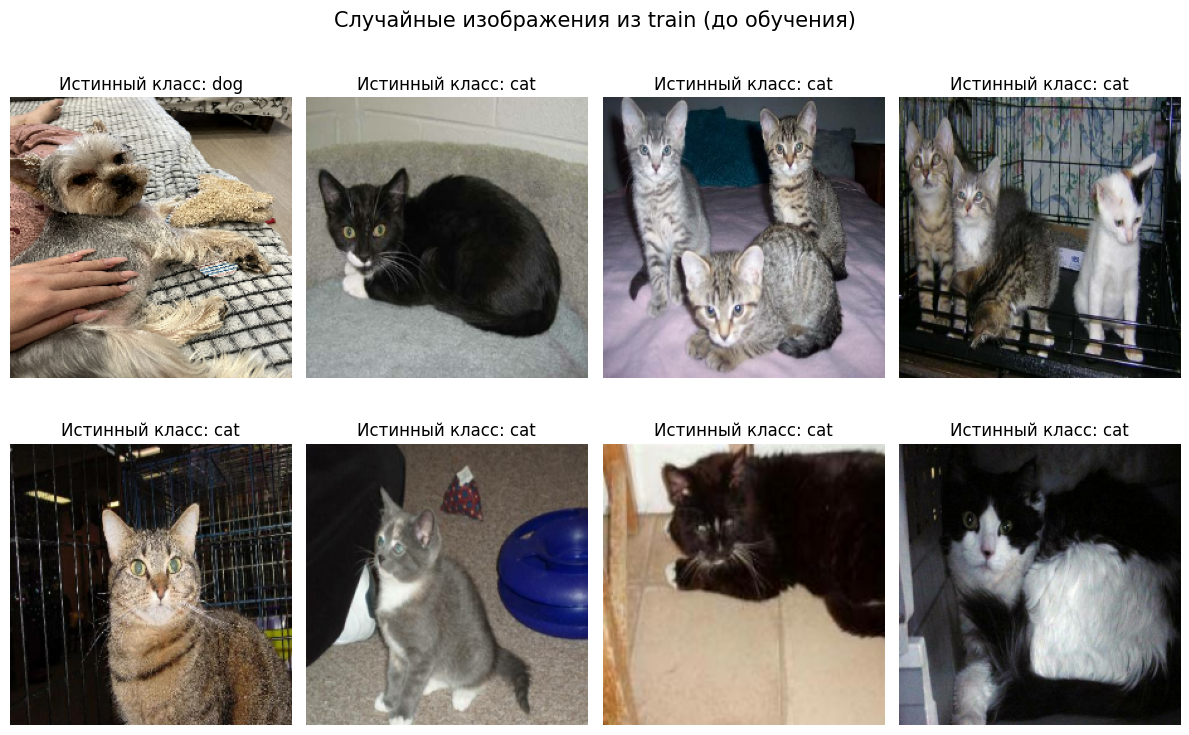

In [4]:
# Keras загрузка и просмотр случайных train‑картинок (как данные выглядят)
def load_with_keras(train_dir: Path, val_dir: Path, test_dir: Path):
    print("=== Загрузка через TensorFlow/Keras ===")

    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        labels="inferred",
        label_mode="int",
        image_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        labels="inferred",
        label_mode="int",
        image_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        labels="inferred",
        label_mode="int",
        image_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names
    print("Классы:", class_names)

    autotune = tf.data.AUTOTUNE
    train_ds = train_ds.prefetch(buffer_size=autotune)
    val_ds = val_ds.prefetch(buffer_size=autotune)
    test_ds = test_ds.prefetch(buffer_size=autotune)

    return train_ds, val_ds, test_ds, class_names


def show_random_train_images_with_labels(dataset, class_names, n=8):
    """Случайные train-изображения с истинными метками (до обучения YOLO)."""
    for images, labels in dataset.take(1):
        n = min(n, len(images))
        idxs = np.random.choice(len(images), size=n, replace=False)

        plt.figure(figsize=(4 * (n // 4 + 1), 8))
        for i, idx in enumerate(idxs):
            ax = plt.subplot(2, int(np.ceil(n / 2)), i + 1)
            img = images[idx].numpy().astype("uint8")
            label = int(labels[idx].numpy())
            ax.imshow(img)
            ax.set_title(f"Истинный класс: {class_names[label]}")
            ax.axis("off")

        plt.suptitle("Случайные изображения из train (до обучения)", fontsize=15)
        plt.tight_layout()
        plt.show()
        break


train_ds, val_ds, test_ds, class_names = load_with_keras(TRAIN_DIR, VAL_DIR, TEST_DIR)
show_random_train_images_with_labels(train_ds, class_names, n=8)

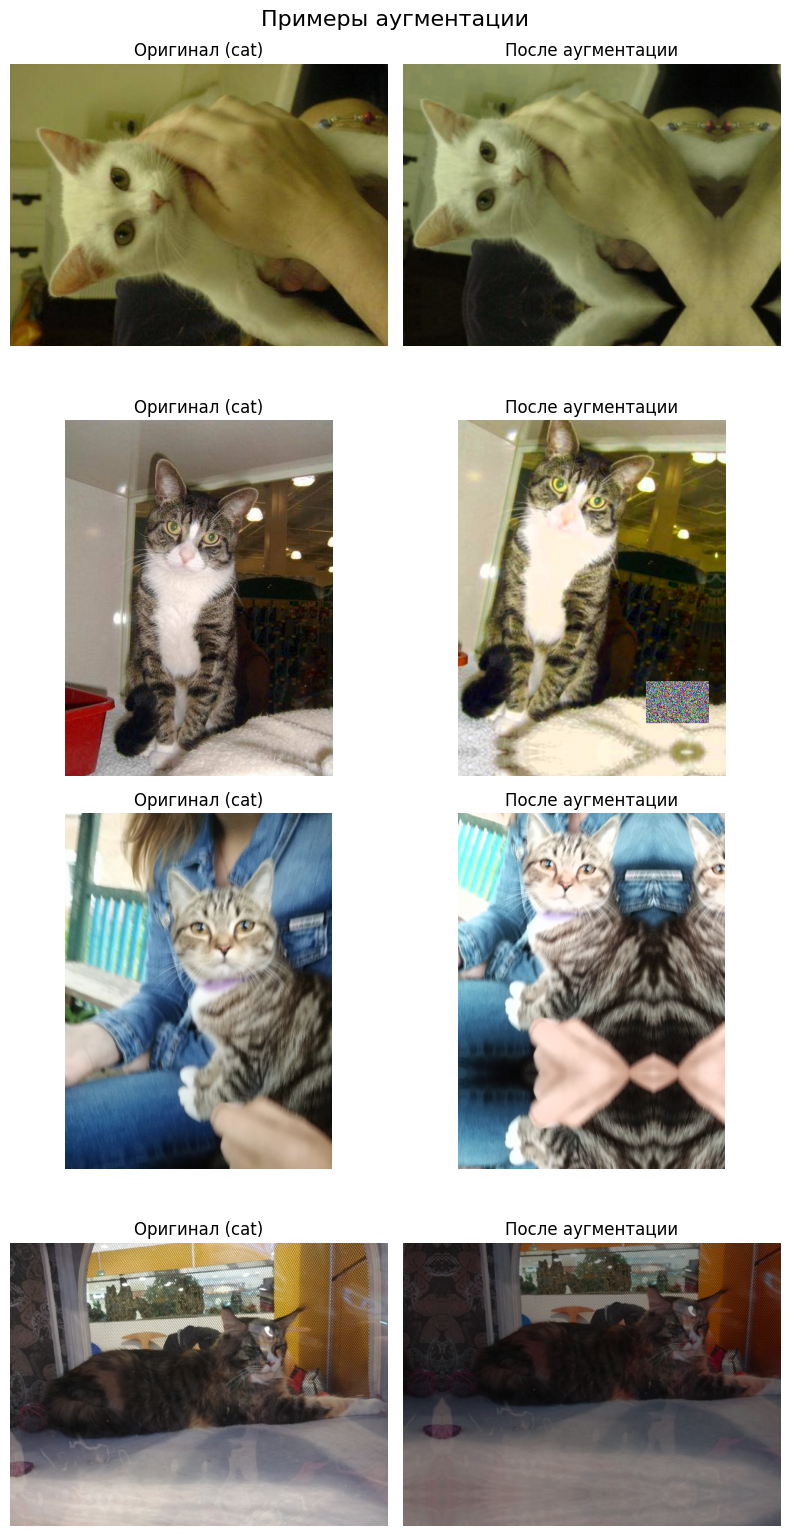

In [5]:
import cv2

def random_augment_opencv(img_bgr):
    """Простая аугментация YOLO."""
    h, w = img_bgr.shape[:2]

    # 1) случайный поворот в диапазоне [-10, 10] градусов
    angle = np.random.uniform(-10, 10)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img_bgr = cv2.warpAffine(img_bgr, M, (w, h),
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_REFLECT_101)

    # 2) случайное масштабирование и сдвиг
    scale = np.random.uniform(0.7, 1.3)     # около scale=0.5 в YOLO
    tx = np.random.uniform(-0.15 * w, 0.15 * w)  # translate ≈ 0.15
    ty = np.random.uniform(-0.15 * h, 0.15 * h)

    M2 = np.float32([[scale, 0, tx],
                     [0, scale, ty]])
    img_bgr = cv2.warpAffine(img_bgr, M2, (w, h),
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_REFLECT_101)

    # 3) изменения HSV (hsv_h, hsv_s, hsv_v)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    # сдвиг оттенка
    img_hsv[..., 0] = (img_hsv[..., 0] + np.random.uniform(-10, 10)) % 180
    # масштаб насыщенности и яркости
    img_hsv[..., 1] *= np.random.uniform(0.6, 1.4)
    img_hsv[..., 2] *= np.random.uniform(0.6, 1.4)
    img_hsv[..., 1:] = np.clip(img_hsv[..., 1:], 0, 255)
    img_bgr = cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    # 4) random erasing (затирание прямоугольника)
    if np.random.rand() < 0.5:
        erase_h = int(h * np.random.uniform(0.1, 0.3))
        erase_w = int(w * np.random.uniform(0.1, 0.3))
        y1 = np.random.randint(0, h - erase_h)
        x1 = np.random.randint(0, w - erase_w)
        img_bgr[y1:y1+erase_h, x1:x1+erase_w] = np.random.randint(
            0, 255, size=(erase_h, erase_w, 3), dtype=np.uint8
        )

    return img_bgr


def show_augmented_examples(root_dir: Path, class_names, n=6):
    """Берёт случайные изображения из train и показывает оригинал + аугментированный вариант."""
    all_images = []
    for cls in class_names:
        class_dir = root_dir / "train" / cls
        if not class_dir.exists():
            continue
        all_images.extend([
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS
        ])

    if not all_images:
        print("Нет изображений для аугментации.")
        return

    n = min(n, len(all_images))
    chosen = random.sample(all_images, k=n)

    plt.figure(figsize=(8, 4 * n))
    for i, img_path in enumerate(chosen):
        # читаем исходную картинку
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # применяем нашу аугментацию
        aug_bgr = random_augment_opencv(img_bgr.copy())
        aug_rgb = cv2.cvtColor(aug_bgr, cv2.COLOR_BGR2RGB)

        # выводим оригинал
        ax1 = plt.subplot(n, 2, 2 * i + 1)
        ax1.imshow(img_rgb)
        ax1.set_title(f"Оригинал ({img_path.parent.name})")
        ax1.axis("off")

        # выводим аугментированный
        ax2 = plt.subplot(n, 2, 2 * i + 2)
        ax2.imshow(aug_rgb)
        ax2.set_title("После аугментации")
        ax2.axis("off")

    plt.suptitle("Примеры аугментации", fontsize=16)
    plt.tight_layout()
    plt.show()


show_augmented_examples(DATASET_ROOT, class_names, n=4)

In [6]:
# YOLO: обучение с аугментацией
model = YOLO(YOLO_MODEL_NAME)

train_results = model.train(
    data=str(DATASET_ROOT),
    epochs=15,           # 10–15, чтобы не дожимать train до 100%
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    seed=SEED,
    device="cpu",
    project="runs",
    name="cats_dogs_yolo_cls_strong_aug",

    # Более мягкий, но стабильный learning rate
    lr0=0.003,          # было 0.005–0.01, делаем ещё плавнее
    lrf=0.01,
    weight_decay=0.0005,

    # ГЕОМЕТРИЧЕСКИЕ АУГМЕНТАЦИИ
    fliplr=0.5,         # горизонтальный флип
    flipud=0.0,         # вертикальный не нужен для котов/собак
    scale=0.5,          # сильнее масштаб (0.0–0.5)
    translate=0.15,     # сдвиг до 15% от размера изображения
    degrees=10.0,       # небольшие повороты ±10°

    # ЦВЕТОВЫЕ АУГМЕНТАЦИИ
    hsv_h=0.03,         # чуть сильнее изменения оттенка
    hsv_s=0.7,          # насыщенность как в “жёстком” режиме
    hsv_v=0.4,          # яркость оставим прежней

    # ПРОСТЕЙШИЙ “ШУМ” / ЗАТИРАНИЕ
    erasing=0.4,        # random erasing до 40% площади патча

    # Дополнительная автоматика аугментаций
    auto_augment="randaugment",  # включаем RandAugment от Ultralytics, если доступно

    # Остальное по умолчанию
    deterministic=True,
    plots=True
)

print("Обучение завершено.")
print("Папка результатов:", train_results.save_dir)

Ultralytics 8.4.37  Python-3.11.0 torch-2.11.0+cpu CPU (AMD Ryzen 5 4600H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\my_dataset, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.03, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cats_dogs_yolo_cls_strong_aug2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

Колонки в results.csv: ['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


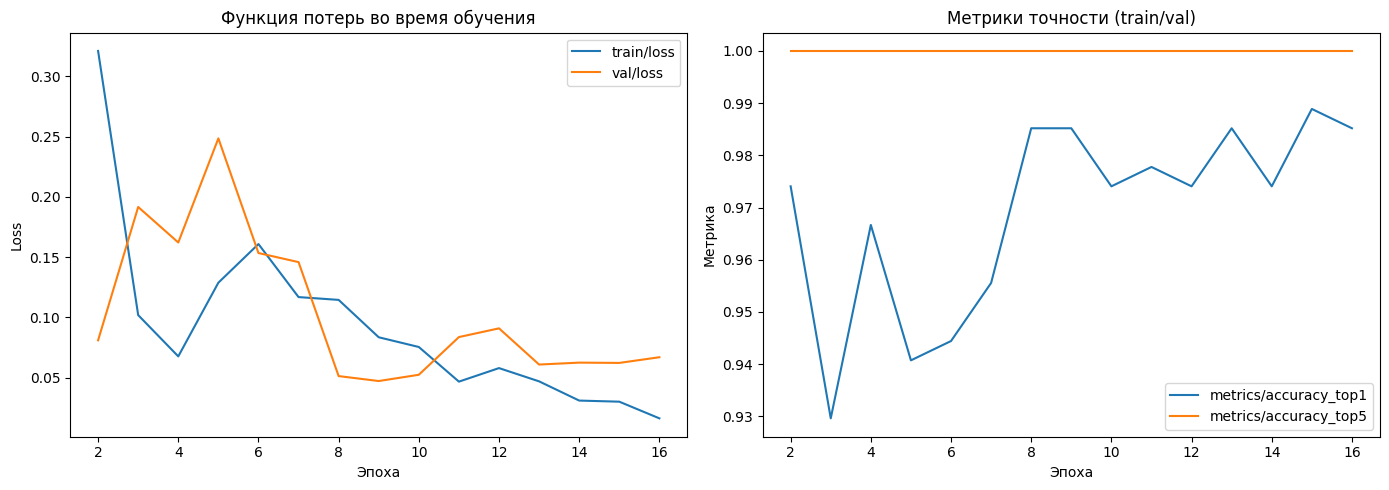

In [7]:
# графики loss и accuracy из results.csv
def plot_yolo_training_curves(save_dir):
    save_dir = Path(save_dir)
    results_csv = save_dir / "results.csv"
    if not results_csv.exists():
        raise FileNotFoundError(f"Не найден файл {results_csv}")

    df = pd.read_csv(results_csv)
    print("Колонки в results.csv:", df.columns.tolist())

    epochs = df["epoch"] + 1

    plt.figure(figsize=(14, 5))

    # Loss
    plt.subplot(1, 2, 1)
    loss_cols = [c for c in df.columns if "loss" in c.lower()]
    for col in loss_cols:
        plt.plot(epochs, df[col], label=col)
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title("Функция потерь во время обучения")
    plt.legend()

    # Accuracy / top1/top5
    plt.subplot(1, 2, 2)
    metric_cols = [c for c in df.columns if any(k in c.lower() for k in ["acc", "top1", "top5"])]
    for col in metric_cols:
        plt.plot(epochs, df[col], label=col)
    plt.xlabel("Эпоха")
    plt.ylabel("Метрика")
    plt.title("Метрики точности (train/val)")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_yolo_training_curves(train_results.save_dir)

In [8]:
# загрузка лучших весов и оценка на test
best_model_path = Path(train_results.save_dir) / "weights" / "best.pt"
best_model = YOLO(str(best_model_path))

val_results = best_model.val(
    data=str(DATASET_ROOT),
    split="test",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    plots=True
)

print("Валидация на test завершена.")
print("Папка валидации:", val_results.save_dir)

Ultralytics 8.4.37  Python-3.11.0 torch-2.11.0+cpu CPU (AMD Ryzen 5 4600H with Radeon Graphics)
YOLO11n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: D:\my_dataset\train... found 1124 images in 2 classes  
val: D:\my_dataset\val... found 270 images in 2 classes  
test: D:\my_dataset\test... found 1658 images in 2 classes  
test: Fast image access  (ping: 0.10.0 ms, read: 1.10.8 MB/s, size: 8.1 KB)
test: Scanning D:\my_dataset\test... 1632 images, 2 corrupt: 100% ━━━━━━━━━━━━ 1632/1632  0.0s
test: D:\my_dataset\test\cat\10369.jpg: corrupt JPEG restored and saved
test: D:\my_dataset\test\cat\117.jpg: corrupt JPEG restored and saved
test: D:\my_dataset\test\cat\140.jpg: ignoring corrupt image/label: Invalid image format GIF. Supported formats are:
images: {'mpo', 'tif', 'heif', 'bmp', 'avif', 'heic', 'jpg', 'png', 'webp', 'dng', 'jpeg2000', 'tiff', 'jp2', 'jpeg'}
videos: {'mkv', 'avi', 'mov', 'asf', 'mpg', 'wmv', 'webm', 'm4v', 'ts', 'mpeg', 'gif', '

In [9]:
# точность на test
def print_test_metrics(val_results):
    print("=== Метрики YOLO на test ===")
    top1 = getattr(val_results, "top1", None)
    top5 = getattr(val_results, "top5", None)

    if top1 is not None:
        print(f"Top-1 accuracy на test: {top1 * 100:.2f}%")
    if top5 is not None:
        print(f"Top-5 accuracy на test: {top5 * 100:.2f}%")

print_test_metrics(val_results)

=== Метрики YOLO на test ===
Top-1 accuracy на test: 70.89%
Top-5 accuracy на test: 100.00%


Не удалось прочитать D:\my_dataset\test\cat\IMG_20250827_093040_208.jpg: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgcodecs\src\loadsave.cpp:1310: error: (-215:Assertion failed) !buf.empty() in function 'cv::imdecode_'

Всего протестировано изображений: 1633


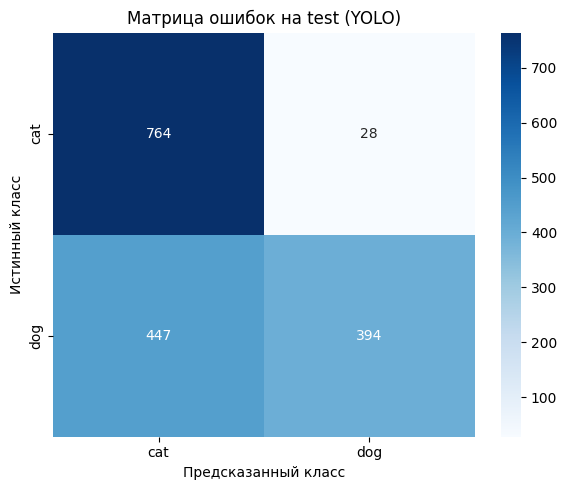

=== Классификационный отчёт по классам ===
              precision    recall  f1-score   support

         cat     0.6309    0.9646    0.7629       792
         dog     0.9336    0.4685    0.6239       841

    accuracy                         0.7091      1633
   macro avg     0.7823    0.7166    0.6934      1633
weighted avg     0.7868    0.7091    0.6913      1633



In [10]:
# матрица ошибок и отчёт по классам (test)
def collect_test_predictions(model, test_dir: Path, class_names):
    """Собирает y_true, y_pred и пути изображений для test, аккуратно пропуская битые файлы."""
    y_true = []
    y_pred = []
    image_paths = []

    class_to_idx = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_dir = test_dir / class_name
        if not class_dir.exists():
            continue

        for img_path in class_dir.iterdir():
            if not img_path.is_file() or img_path.suffix.lower() not in SUPPORTED_EXTS:
                continue

            # защищаемся от битых файлов / HEIC / проблем чтения
            try:
                results = model(str(img_path), verbose=False)
            except Exception as e:
                print(f"Не удалось прочитать {img_path}: {e}")
                continue

            probs = results[0].probs
            pred_idx = int(probs.top1)

            y_true.append(class_to_idx[class_name])
            y_pred.append(pred_idx)
            image_paths.append(img_path)

    return np.array(y_true), np.array(y_pred), image_paths


# собираем предсказания
y_true, y_pred, image_paths = collect_test_predictions(best_model, TEST_DIR, class_names)

print(f"Всего протестировано изображений: {len(y_true)}")

# если вдруг в test оказался только один класс, руками задаём labels
all_labels = np.arange(len(class_names))

cm = confusion_matrix(y_true, y_pred, labels=all_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок на test (YOLO)")
plt.tight_layout()
plt.show()

print("=== Классификационный отчёт по классам ===")
print(classification_report(
    y_true,
    y_pred,
    labels=all_labels,          # явно указываем все индексы классов
    target_names=class_names,   # имена классов
    digits=4
))

In [11]:
# точность на test 
test_accuracy = (y_true == y_pred).mean() * 100 if len(y_true) > 0 else 0.0
print(f"Точность на тестовой выборке (по нашим предсказаниям): {test_accuracy:.2f}%")

Точность на тестовой выборке (по нашим предсказаниям): 70.91%


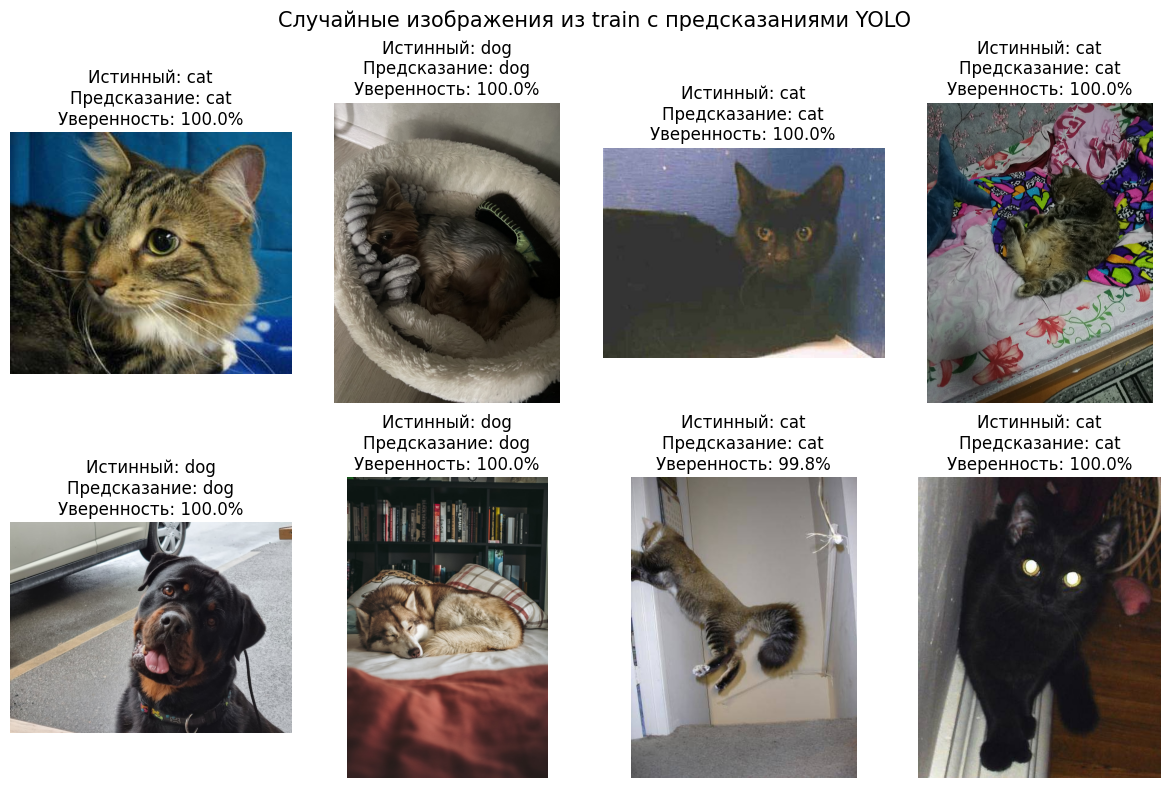

In [30]:
# случайные train‑картинки с предсказаниями YOLO (как модель научилась)
def show_random_train_images_with_yolo_preds(model, train_dir: Path, class_names, n=8):
    all_images = []
    for class_name in class_names:
        class_dir = train_dir / class_name
        if not class_dir.exists():
            continue
        all_images.extend([
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS
        ])

    if not all_images:
        print("В train нет изображений поддерживаемых форматов.")
        return

    n = min(n, len(all_images))
    chosen = random.sample(all_images, k=n)

    plt.figure(figsize=(4 * (n // 4 + 1), 8))
    for i, img_path in enumerate(chosen):
        results = model(str(img_path), verbose=False)
        probs = results[0].probs
        pred_idx = int(probs.top1)
        pred_name = results[0].names[pred_idx]
        conf = float(probs.top1conf)

        true_class = img_path.parent.name
        img = Image.open(img_path).convert("RGB")

        ax = plt.subplot(2, int(np.ceil(n / 2)), i + 1)
        ax.imshow(img)
        ax.set_title(
            f"Истинный: {true_class}\n"
            f"Предсказание: {pred_name}\n"
            f"Уверенность: {conf * 100:.1f}%"
        )
        ax.axis("off")

    plt.suptitle("Случайные изображения из train с предсказаниями YOLO", fontsize=15)
    plt.tight_layout()
    plt.show()


show_random_train_images_with_yolo_preds(best_model, TRAIN_DIR, class_names, n=8)

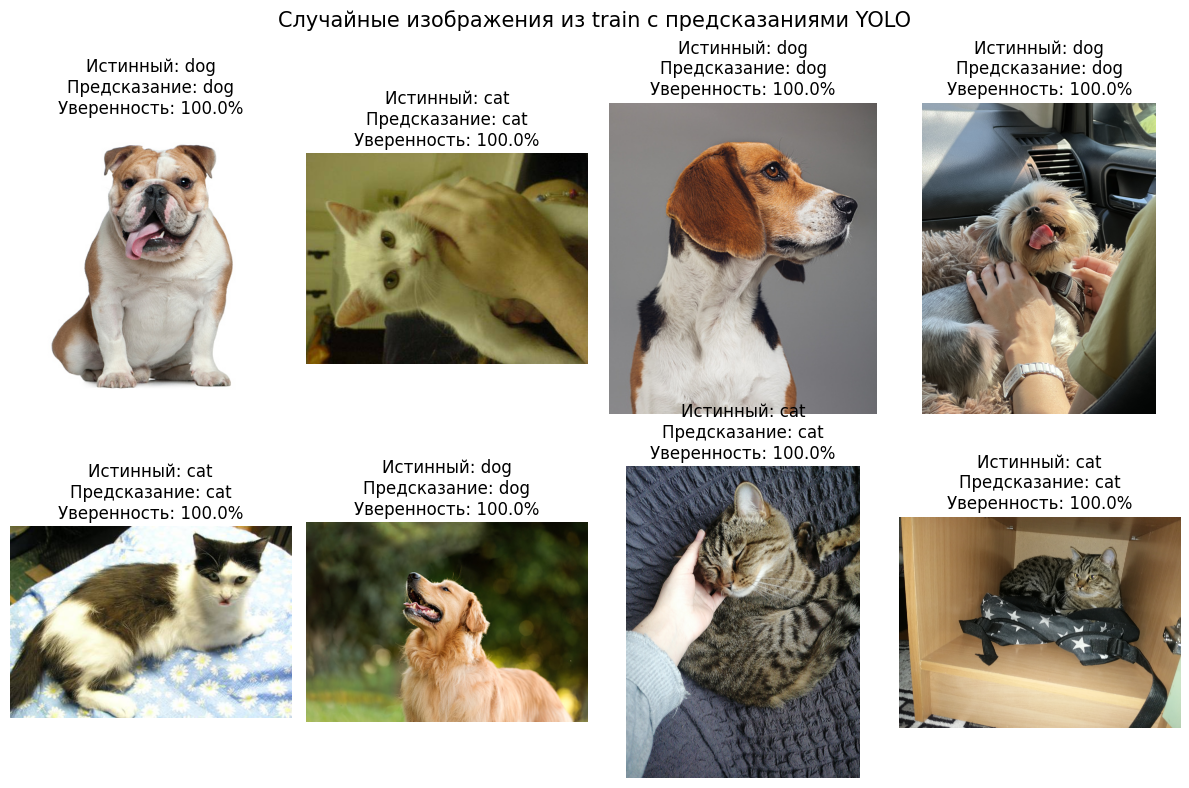

In [26]:
# случайные train‑картинки с предсказаниями YOLO (как модель научилась)
def show_random_train_images_with_yolo_preds(model, train_dir: Path, class_names, n=8):
    all_images = []
    for class_name in class_names:
        class_dir = train_dir / class_name
        if not class_dir.exists():
            continue
        all_images.extend([
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS
        ])

    if not all_images:
        print("В train нет изображений поддерживаемых форматов.")
        return

    n = min(n, len(all_images))
    chosen = random.sample(all_images, k=n)

    plt.figure(figsize=(4 * (n // 4 + 1), 8))
    for i, img_path in enumerate(chosen):
        results = model(str(img_path), verbose=False)
        probs = results[0].probs
        pred_idx = int(probs.top1)
        pred_name = results[0].names[pred_idx]
        conf = float(probs.top1conf)

        true_class = img_path.parent.name
        img = Image.open(img_path).convert("RGB")

        ax = plt.subplot(2, int(np.ceil(n / 2)), i + 1)
        ax.imshow(img)
        ax.set_title(
            f"Истинный: {true_class}\n"
            f"Предсказание: {pred_name}\n"
            f"Уверенность: {conf * 100:.1f}%"
        )
        ax.axis("off")

    plt.suptitle("Случайные изображения из train с предсказаниями YOLO", fontsize=15)
    plt.tight_layout()
    plt.show()


show_random_train_images_with_yolo_preds(best_model, TRAIN_DIR, class_names, n=8)

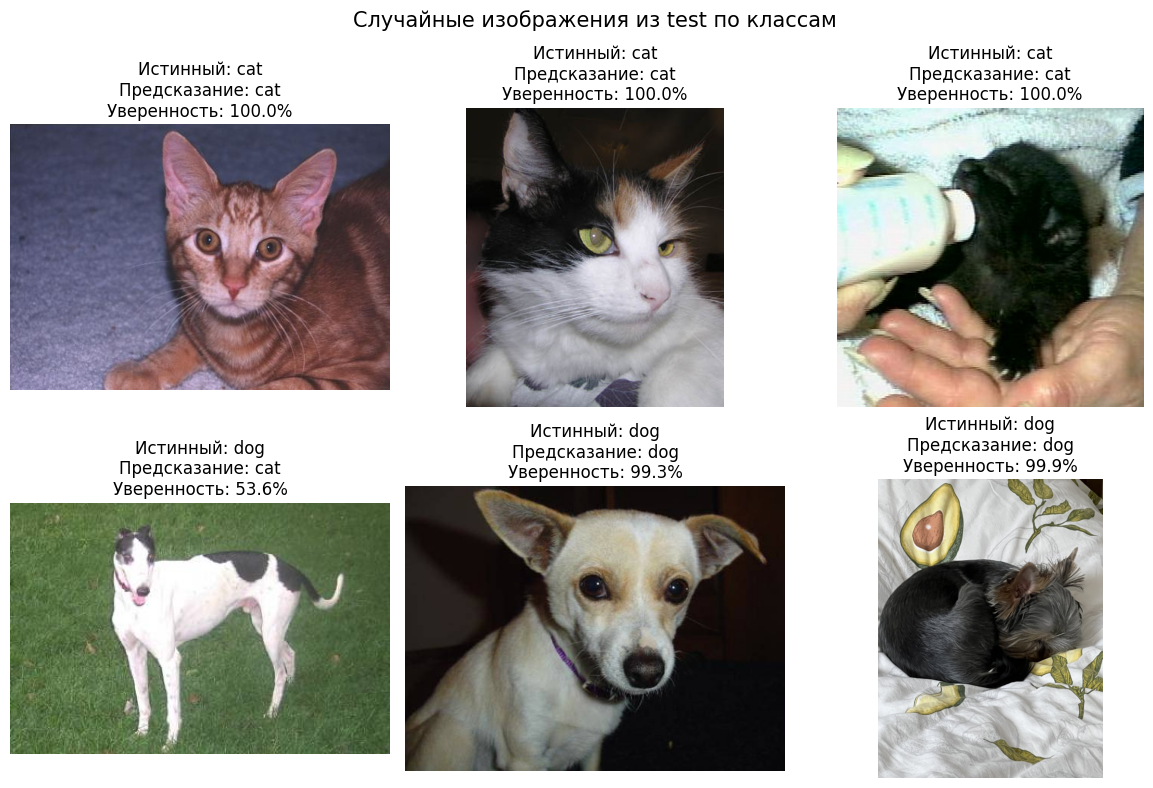

In [14]:
# случайные картинки из test по двум классам с предсказаниями
def show_random_test_images_by_class(model, test_dir: Path, class_names, n_per_class=3):
    rows = len(class_names)
    cols = n_per_class
    plt.figure(figsize=(4 * cols, 4 * rows))

    plot_idx = 1
    for class_name in class_names:
        class_dir = test_dir / class_name
        images = [
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS
        ]

        if len(images) == 0:
            continue

        chosen = random.sample(images, k=min(n_per_class, len(images)))

        for img_path in chosen:
            results = model(str(img_path), verbose=False)
            probs = results[0].probs
            pred_idx = int(probs.top1)
            pred_name = results[0].names[pred_idx]
            conf = float(probs.top1conf)

            img = Image.open(img_path).convert("RGB")

            ax = plt.subplot(rows, cols, plot_idx)
            ax.imshow(img)
            ax.set_title(
                f"Истинный: {class_name}\n"
                f"Предсказание: {pred_name}\n"
                f"Уверенность: {conf * 100:.1f}%"
            )
            ax.axis("off")
            plot_idx += 1

    plt.suptitle("Случайные изображения из test по классам", fontsize=15)
    plt.tight_layout()
    plt.show()


show_random_test_images_by_class(best_model, TEST_DIR, class_names, n_per_class=3)

In [15]:
from ultralytics import YOLO

model = YOLO("yolo11n-cls.pt")  # или best.pt
model.info(verbose=True)

YOLO11n-cls summary: 86 layers, 2,812,104 parameters, 0 gradients, 4.3 GFLOPs


(86, 2812104, 0, 4.2763264)

In [16]:


import torch
from torchviz import make_dot
from ultralytics import YOLO

model = YOLO("yolo11n-cls.pt")
torch_model = model.model  # "голая" PyTorch-сеть

x = torch.zeros(1, 3, 224, 224)  # тестовый вход
y = torch_model(x)

dot = make_dot(y, params=dict(list(torch_model.named_parameters())))
dot.format = 'png'
dot.directory = 'output'
dot.render('yolo11_cls_graph')

from IPython.display import Image
Image(filename='output/yolo11_cls_graph.png')

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [ ]:
from torchinfo import summary
from ultralytics import YOLO

model = YOLO("yolo11n-cls.pt")
torch_model = model.model

summary(torch_model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                                       Output Shape              Param #
ClassificationModel                                          [1, 1000]                 --
├─Sequential: 1-1                                            --                        --
│    └─Conv: 2-1                                             [1, 16, 112, 112]         --
│    │    └─Conv2d: 3-1                                      [1, 16, 112, 112]         (432)
│    │    └─BatchNorm2d: 3-2                                 [1, 16, 112, 112]         (32)
│    └─Classify: 2-68                                        --                        (recursive)
│    │    └─Conv: 3-74                                       --                        (recursive)
│    └─Conv: 2-3                                             [1, 32, 56, 56]           --
│    │    └─Conv2d: 3-4                                      [1, 32, 56, 56]           (4,608)
│    │    └─BatchNorm2d: 3-5                                 [1, 32